In [1]:
from datasets import load_dataset as hf_load

cppe5 = hf_load("rishitdagli/cppe-5")
for split_name, split in cppe5.items():
    print(f"{split_name}: {len(split)} images")

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train: 1000 images
test: 29 images


In [2]:
from pathlib import Path

from datasets import Dataset

data_path = Path("./data/cppe5")


def write_imagefolder(hf_dataset: Dataset, root: Path) -> None:
    """Write a HuggingFace object-detection split in the ImageFolder convention."""
    root.mkdir(parents=True, exist_ok=True)
    for stale in root.glob("metadata.*"):  # a leftover metadata file is read alongside the new one
        stale.unlink()

    file_names = []
    for seq, example in enumerate(hf_dataset):
        file_name = f"{seq:05d}.jpg"
        example["image"].convert("RGB").save(root / file_name, quality=95)
        file_names.append(file_name)

    # Carry the source `objects` column through untouched so its `category` ClassLabel — the
    # Coverall/Face_Shield/... name table — lands in the parquet features schema.
    metadata = hf_dataset.remove_columns(["image", "image_id", "width", "height"]).add_column("file_name", file_names)
    metadata.to_parquet(root / "metadata.parquet")


for split_name, split in cppe5.items():
    write_imagefolder(split, data_path / split_name)

print(f"Wrote {data_path}/train and {data_path}/test")

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 380.75ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 1467.57ba/s]

Wrote data/cppe5/train and data/cppe5/test


In [3]:
from dataeval_flow import load_dataset

train_ds = load_dataset(data_path, split="train", dataset_format="huggingface", task="object_detection")
image, target, _ = train_ds[0]

print(f"Images:      {len(train_ds)}")
print(f"Image shape: {image.shape}")
print(f"Boxes:       {len(target.boxes)}")
print(f"Classes:     {train_ds.metadata['index2label']}")

Images:      1000
Image shape: (3, 663, 943)
Boxes:       4
Classes:     {0: 'Coverall', 1: 'Face_Shield', 2: 'Gloves', 3: 'Goggles', 4: 'Mask'}


In [4]:
config_path = Path("end_to_end.yaml")
print(config_path.read_text())

# End-to-end pipeline — clean, profile, and split one dataset
#
# This is the single source of truth for the `end_to_end` tutorial. The notebook
# loads this exact file, and the container runs this exact file — nothing in the
# pipeline is defined in Python.
#
# All paths are relative to the data root:
#   * notebook  — docs/source/notebooks/
#   * container — the directory bind-mounted at /dataeval
#
# Run it locally:
#   dataeval-flow --config end_to_end.yaml --data . --output ./output --cache ./cache -v
#
# yaml-language-server: $schema=../../../config/params.schema.json

# Pin every stochastic component (clustering, splitting) so re-runs match.
seed: 42

# -----------------------------------------------------------------------------
# DATASETS — where the data lives and how to read it
# -----------------------------------------------------------------------------
datasets:
  - name: cppe5_train
    format: huggingface
    path: data/cppe5
    split: train
    task: object_detection

In [5]:
from dataeval_flow import load_config

config = load_config(config_path)

print(f"Datasets:   {[d.name for d in config.datasets]}")
print(f"Sources:    {[s.name for s in config.sources]}")
print(f"Extractors: {[e.name for e in config.extractors]}")
print(f"Workflows:  {[(w.name, w.type) for w in config.workflows]}")
print(f"Tasks:      {[(t.name, t.workflow, t.sources) for t in config.tasks]}")

Datasets:   ['cppe5_train', 'cppe5_test']
Sources:    ['train_src', 'test_src']
Extractors: ['bovw_ext']
Workflows:  [('clean', 'data-cleaning'), ('profile', 'data-analysis'), ('split', 'data-splitting')]
Tasks:      [('clean_train', 'clean', 'train_src'), ('profile_splits', 'profile', ['train_src', 'test_src']), ('split_train', 'split', 'train_src')]


In [6]:
from dataeval_flow import run_tasks

results = run_tasks(config, data_dir=Path("."), cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/cleaning/workflow.py:277: UserWarning: `height` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  td = metadata.rows_at(metadata.label_level).select("item_index", "target_index", "class_label")


/builds/jatic/aria/dataeval-flow/src/dataeval_flow/binning.py:111: UserWarning: `height`, `instance_aspect_ratio`, `instance_brightness`, `instance_contrast`, `instance_darkness`, `instance_distance_center`, `instance_distance_edge`, `instance_entropy`, `instance_height`, `instance_kurtosis`, `instance_mean`, `instance_offset_x`, `instance_offset_y`, `instance_sharpness`, `instance_size`, `instance_skew`, `instance_std`, `instance_var`, `instance_width`, `instance_zeros`, `unit_aspect_ratio`, `unit_brightness`, `unit_contrast`, `unit_darkness`, `unit_entropy`, `unit_height`, `unit_kurtosis`, `unit_mean`, `unit_sharpness`, `unit_size`, `unit_skew`, `unit_std`, `unit_var`, `unit_width`, `unit_zeros` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control 

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/splitting/workflow.py:221: UserWarning: `file_name`, `id` and `source_file_name` were dropped: nearly every row holds a different value, so the column identifies rows rather than grouping them, and it is not numeric so there is no order along which to cut it into groups. Map the values onto a smaller vocabulary to keep the factor. See Metadata.dropped_factors.
  balance_output = Balance().evaluate(metadata)
/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/splitting/workflow.py:221: UserWarning: `height` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  balance_output = Balance().evaluate(metadata)


In [7]:
for task, result in zip(config.tasks, results, strict=True):
    status = "OK " if result.success else "FAIL"
    warnings = sum(1 for f in result.data.report.findings if f.severity == "warning")
    elapsed = result.metadata.execution_time_s or 0.0
    print(f"[{status}] {task.name:<16} {result.name:<16} {elapsed:>6.1f}s  {warnings} warning(s)")
    for error in result.errors:
        print(f"         {error}")

[OK ] clean_train      data-cleaning       0.6s  1 warning(s)
[OK ] profile_splits   data-analysis      21.6s  5 warning(s)
[OK ] split_train      data-splitting      5.0s  1 warning(s)


In [8]:
assert all(r.success for r in results), [r.errors for r in results if not r.success]

In [9]:
clean_result, profile_result, split_result = results

In [10]:
for result in results:
    print(result.report(detailed=False))


  DATA CLEANING COMPLETE. DATASET: 250 ITEMS. MODE: ADVISORY.
  Timestamp:    2026-09-04T07:22:57.562945+00:00
  Duration:     0.62s
  Source:       train_src (cppe5_train[first_250])
  Model:        bovw_ext (bovw)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Image Outliers ..................................... 26 images (10.4%)  [!!]
  Target Outliers .................................... 91 targets (7.7%)  [..]
  Classwise Outliers worst: Coverall (11.5%), all classes within 12.0%  [..]
  Duplicates ............................. 0 exact (0.0%), 9 near (3.6%)  [..]
  Label Distribution ............. 5 classes, 250 items, imbalance 3.6:1  [..]

  Health: 1 warning(s) [!!] — review flagged findings

--------------------------------------------------------------------------------
  METADATA FACTORS
--------------------------------------------------------------------------------
  Encoding:        be8f09b313560ae3
  Auto-bin meth

In [11]:
for result in results:
    print(f"\n{result.name}")
    for finding in result.data.report.findings:
        marker = {"warning": "[!!]", "ok": "[ok]"}.get(finding.severity, "[..]")
        headline = (finding.description or "").splitlines()
        print(f"  {marker} {finding.title:<34} {headline[0][:60] if headline else ''}")


data-cleaning
  [!!] Image Outliers                     26 images (10.4%) flagged as outliers.
  [..] Target Outliers                    91 bounding-box targets (7.7%) flagged as outliers.
  [..] Classwise Outliers                 Most outliers in Coverall (11.5%). 0/5 classes exceed 12.0% 
  [..] Duplicates                         0 exact duplicate groups, 4 near-duplicate groups found.
  [..] Label Distribution                 5 classes, 250 items.

data-analysis
  [!!] Image Quality                      26 images flagged across 2 split(s).
  [!!] Redundancy                         0 exact + 11 near duplicates across 2 split(s).
  [..] Label Balance                      5 classes across 2 split(s).
  [!!] Bias                               50 metadata factors checked across 2 split(s).
  [ok] Label Overlap                      All 5 classes shared across splits.
  [!!] Label Parity                       Chi-squared test: 1/1 pair(s) significantly different.
  [!!] Leakage           

In [12]:
raw = clean_result.data.raw

outlier_issues = raw.img_outliers["issues"]
outlier_indices = sorted({issue["item_index"] for issue in outlier_issues})
near_groups = raw.duplicates["items"].get("near", [])

print(f"Image outliers:        {len(outlier_indices)} images, {len(outlier_issues)} flags")
print(f"Near-duplicate groups: {len(near_groups)}")

Image outliers:        26 images, 31 flags
Near-duplicate groups: 4


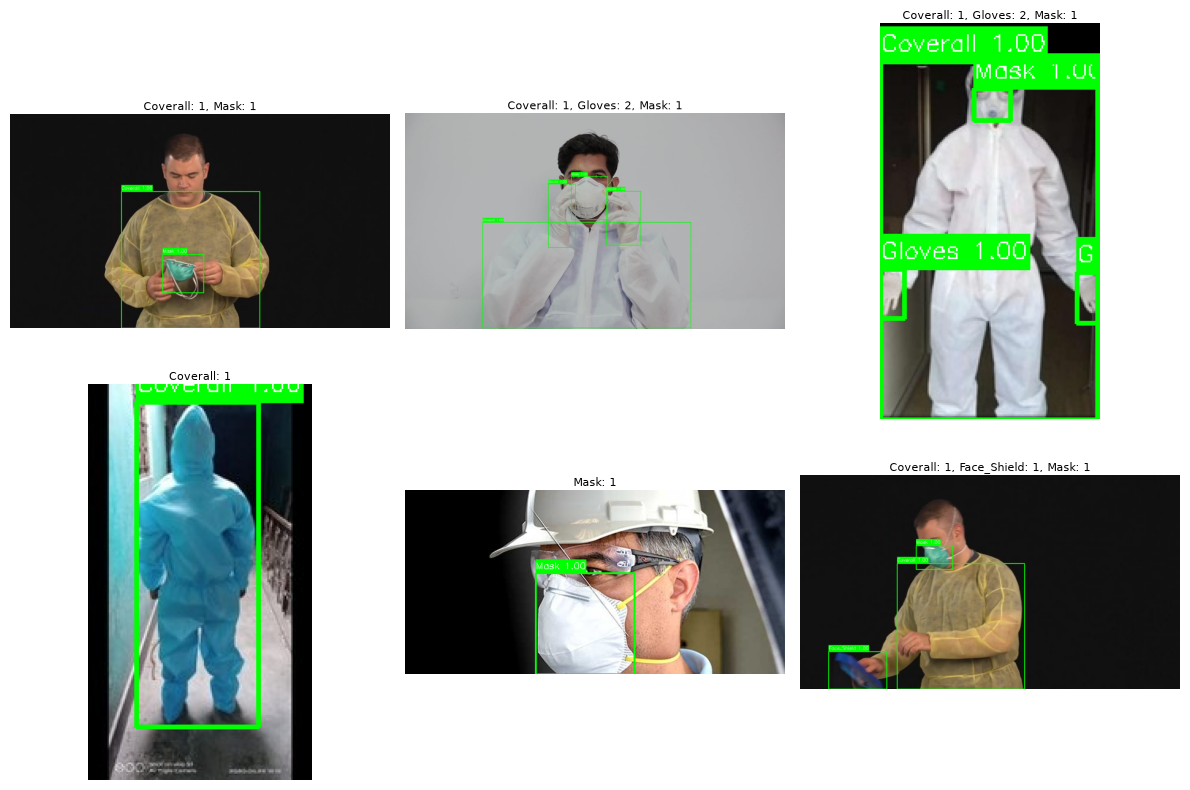

In [13]:
from dataeval_plots import plot

assert clean_result.dataset is not None

if outlier_indices:
    _ = plot(
        clean_result.dataset,
        indices=outlier_indices[:6],
        images_per_row=3,
        figsize=(12, 8),
        show_labels=True,
    )

In [14]:
print(f"Splits analyzed: {profile_result.metadata.split_names}")

for pair, section in profile_result.data.raw.cross_split.items():
    cs = section.model_dump()
    leakage = cs["redundancy"]["duplicate_leakage"]
    overlap = cs["label_health"]["label_overlap"]
    parity = cs["label_health"]["label_parity"]

    only = {key: value for key, value in overlap.items() if key.endswith("_only")}

    print(f"\n{pair}")
    print(f"  Duplicate leakage:  {leakage['exact_count']} exact, {leakage['near_count']} near")
    print(f"  Shared classes:     {overlap['shared_classes']}")
    print(f"  Classes in one split only: {only}")
    print(
        f"  Label parity:       chi2={parity['chi_squared']:.2f}, "
        f"p={parity['p_value']:.4f}, significant={parity['significant']}"
    )

Splits analyzed: ['train_src', 'test_src']

train_src_vs_test_src
  Duplicate leakage:  0 exact, 6 near
  Shared classes:     ['Coverall', 'Face_Shield', 'Gloves', 'Goggles', 'Mask']
  Classes in one split only: {'train_src_only': [], 'test_src_only': []}
  Label parity:       chi2=14.75, p=0.0052, significant=True


In [15]:
fold = split_result.data.raw.folds[0]

print(f"Split sizes: {split_result.metadata.split_sizes}")
print(f"Stratified:  {split_result.metadata.stratified}")
print(f"Train indices (first 10): {fold.train_indices[:10]}")
print(f"Val   indices (first 10): {fold.val_indices[:10]}")
print(f"Test  indices (first 10): {split_result.data.raw.test_indices[:10]}")

Split sizes: {'train': 185, 'val': 16, 'test': 49}
Stratified:  True
Train indices (first 10): [0, 1, 2, 4, 5, 6, 7, 8, 9, 10]
Val   indices (first 10): [30, 38, 46, 77, 87, 90, 132, 133, 139, 148]
Test  indices (first 10): [3, 17, 18, 24, 27, 37, 42, 43, 44, 48]


In [16]:
output_dir = Path("./output/end_to_end")

for task, result in zip(config.tasks, results, strict=True):
    written = result.export(output_dir / f"{task.name}.json")
    print(f"{written}  ({written.stat().st_size:,} bytes)")

output/end_to_end/clean_train.json  (39,177 bytes)
output/end_to_end/profile_splits.json  (1,688,028 bytes)
output/end_to_end/split_train.json  (23,278 bytes)


In [17]:
import json

envelope = json.loads((output_dir / "split_train.json").read_text())

print(f"Top-level keys: {list(envelope)}")
print(f"Tool:           {envelope['metadata']['tool']} {envelope['metadata']['tool_version']}")
print(f"Timestamp:      {envelope['metadata']['timestamp']}")
print(f"Sources:        {envelope['metadata']['source_descriptions']}")

Top-level keys: ['metadata', 'health', 'raw', 'report']
Tool:           dataeval-flow 0.2.3.dev23+gbcbf4d4c6
Timestamp:      2026-09-04T07:23:26.228049Z
Sources:        ['train_src (cppe5_train[first_250])']
